# Attribution Visualisation

This notebook produces the main result figures for the non-stationary Markov chain
attribution analysis of heatwaves over Europe.

**What it does:**

1. Loads the fitted model output (NetCDF) for all 9 CMIP6 models
   (Model 1: constant threshold, Model 2: time-varying threshold).
2. Computes the annual log-likelihood ratio (log LR) between the historical and
   hist-nat scenarios evaluated on the ERA5 observational time series.
3. Produces three figures:
   - `all_parameters_reg_19_tasmax.png` – time series of fitted Markov-GPD parameters
     (φ, σ, ξ, α) for both model types and both forcing scenarios.
   - `fig11.png` – annual log LR 2000–2025 with multi-model mean ± spread and
     number of ERA5 threshold exceedances per year (different to the paper, since no ensemble and random effects model is used here)
   - `summer_compare.png` – cumulative log LR over the summers of 2022 and 2025
     per model, with multi-model mean ± spread at the end of the season.

**Input data:** `epi_output/` (EPI from CMIP6 simulations and ERA5) must be present.
All functions shared with the analysis pipeline are imported from `markov_functions.py`.

## 1. Imports & configuration

In [1]:
import warnings

import cartopy.crs as ccrs
import glob
import os
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.lines import Line2D
from scipy.stats import genpareto

from markov_functions import (
    get_pairwise_timeseries_from_univariate,
    read_in_file,
    run_quantile_regression,
)

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

In [2]:
INPUT_DIR  = "/home/b/b382884/Non-stationary-time-series-attribution-for-heatwaves-over-Europe/epi_output/"
RESULT_DIR = "/work/bm1159/XCES/xces-work/b382884/MYWORK/git_code_test/reg_19/without_seasonal_cycle"

REGION = 'reg_19'
Q      = 0.95
MAX_DEG = 5

era5_files = glob.glob(os.path.join(INPUT_DIR, REGION, "ERA5", "*", "*.nc"))
if not era5_files:
    raise FileNotFoundError(
        f"No ERA5 .nc file found under {os.path.join(INPUT_DIR, REGION, 'ERA5')}"
    )
ERA5_PATH = era5_files[0]
print(f"ERA5 file : {ERA5_PATH}")


MODELS = ["access", "bcc", "canesm5", "cnrm", "hadgem3",
          "ipsl", "miroc6", "mpi", "mri"]

MODEL_COLORS = [
    '#ff7f0e',  # Orange
    '#2ca02c',  # Grün
    '#d62728',  # Rot
    '#9467bd',  # Lila
    '#8c564b',  # Braun
    '#e377c2',  # Rosa
    '#7f7f7f',  # Grau
    '#bcbd22',  # Oliv
    '#17becf',  # Cyan
]

RENAME_MAP = {"phihistnat": "phi_histnat"}

ERA5 file : /home/b/b382884/Non-stationary-time-series-attribution-for-heatwaves-over-Europe/epi_output/reg_19/ERA5/943352/ExtremalPatternIndex_TPDM.nc


## 2. Helper functions

Functions used for the likelihood computation and plotting.
`univariate_density`, `bivariate_likelihood`, and `markov_log_likelihood` implement
the first-order Markov chain likelihood following Smith et al. (1997).
`calculate_probability_ratio` evaluates Model 1 (constant threshold) and
`calculate_probability_ratio2` evaluates Model 2 (time-varying threshold) on the ERA5
time series for every year 1940–2025.
`get_pairwise_timeseries_from_univariate`, `read_in_file`, and `run_quantile_regression`
are imported from `markov_functions.py`.

## 2. Helper functions

In [3]:
def univariate_density(y, xi, scale, thres, phi):
    if y - thres >= 0:
        return phi * genpareto.pdf(y, c=xi, loc=thres, scale=scale)
    return 1 - phi


def bivariate_likelihood(idx, lam, sigma, xi, u, alpha, biv):
    """Bivariate copula-GPD likelihood for a single consecutive pair."""
    def _V(z1, z2, a):  return (z1**(-1/a) + z2**(-1/a))**a
    def _V1(z1, z2, a): return -(z1**(-1/a) + z2**(-1/a))**(a-1) * z1**(-1/a-1)
    def _V2(z1, z2, a): return -(z1**(-1/a) + z2**(-1/a))**(a-1) * z2**(-1/a-1)
    def _V12(z1, z2, a):
        return (a-1)/a * (z1**(-1/a) + z2**(-1/a))**(a-2) * z1**(-1/a-1) * z2**(-1/a-1)

    r1 = -1 / np.log(1 - lam[0]);  r2 = -1 / np.log(1 - lam[1])
    t1 = (1 + xi[0]*(biv[0]-u)/sigma[0])**(-1/xi[0])
    t2 = (1 + xi[1]*(biv[1]-u)/sigma[1])**(-1/xi[1])
    z1 = -1/np.log(1 - lam[0]*t1);  z2 = -1/np.log(1 - lam[1]*t2)
    K1 = -lam[0]/sigma[0] * t1**(1+xi[0]) * z1**2 * np.exp(1/z1)
    K2 = -lam[1]/sigma[1] * t2**(1+xi[1]) * z2**2 * np.exp(1/z2)

    term_both  = np.exp(-_V(z1,z2,alpha)) * (_V1(z1,z2,alpha)*_V2(z1,z2,alpha) - _V12(z1,z2,alpha)) * K1*K2
    term_only2 = np.exp(-_V(r1,z2,alpha)) * _V2(r1,z2,alpha) * K2
    term_only1 = np.exp(-_V(z1,r2,alpha)) * _V1(z1,r2,alpha) * K1
    term_none  = np.exp(-_V(r1,r2,alpha))

    if   idx[0]==1 and idx[1]==1: return term_both
    elif idx[0]==0 and idx[1]==1: return term_only2
    elif idx[0]==1 and idx[1]==0: return term_only1
    return term_none


def markov_log_likelihood(xi, scale, thres, phi, alpha, idx_pairs, ts, biv):
    """Cumulative log-likelihood of the Markov chain over one summer."""
    phi_biv   = get_pairwise_timeseries_from_univariate(phi)
    scale_biv = get_pairwise_timeseries_from_univariate(scale)
    shape_biv = get_pairwise_timeseries_from_univariate(xi)

    f1 = np.array([univariate_density(ts[i], xi[i], scale[i], thres[i], phi[i]) for i in range(len(ts))])
    f2 = np.array([bivariate_likelihood(idx_pairs[i], phi_biv[i], scale_biv[i], shape_biv[i], thres[i], alpha[i], biv[i])
                   for i in range(len(ts)-1)])

    cond = f2 / f1[:-1]
    return np.array([np.log(f1[0]) + np.nansum(np.log(cond[:i])) for i in range(1, len(ts))])


def load_and_fix(path):
    ds = xr.open_dataset(path)
    for old, new in RENAME_MAP.items():
        if old in ds:
            ds = ds.rename({old: new})
    return ds


def _extend_to_2025(model):
    s2024 = model.sel(time=slice("2024-06-01", "2024-08-31"))
    s2025 = s2024.copy().assign_coords(time=pd.date_range("2025-06-01", "2025-08-31", freq="D"))
    return xr.concat([model, s2025], dim="time")


def calculate_probability_ratio(model, era5_ds):
    """Log-likelihood ratio per year – Model 1 (constant threshold)."""
    m      = _extend_to_2025(model)
    n_yrs  = len(era5_ds.EPI.groupby("time.year"))
    thres  = np.repeat(era5_ds.EPI.quantile(Q).values, 92)
    biv    = get_pairwise_timeseries_from_univariate(era5_ds.EPI.values)

    ll_hist = np.full((n_yrs, 91), np.nan)
    ll_nat  = np.full((n_yrs, 91), np.nan)
    diff    = np.full(n_yrs, np.nan)

    for i in range(n_yrs):
        yr  = 1940 + i
        ts  = era5_ds.EPI.sel(time=str(yr)).values
        bv  = biv[i*92:i*92+92]
        idx = np.where(bv > era5_ds.EPI.quantile(Q).values, 1, 0)

        def _ll(scenario):
            return markov_log_likelihood(
                m[f"shape_{scenario}"].sel(time=str(yr)).values,
                m[f"scale_{scenario}"].sel(time=str(yr)).values,
                thres, m[f"phi_{scenario}"].sel(time=str(yr)).values,
                m[f"alpha_{scenario}"].sel(time=str(yr)).values,
                idx, ts, bv)

        ll_hist[i] = _ll("hist");  ll_nat[i] = _ll("histnat")
        diff[i] = ll_hist[i][-1] - ll_nat[i][-1]

    ds = xr.Dataset({"pr": ("year", diff)}, coords={"year": np.arange(1940, 2026)})
    return ds, ll_hist, ll_nat


def calculate_probability_ratio2(model, era5_ds):
    """Log-likelihood ratio per year – Model 2 (time-varying threshold)."""
    m        = _extend_to_2025(model)
    n_yrs    = len(era5_ds.EPI.groupby("time.year"))
    data_e5  = read_in_file(ERA5_PATH)
    qm_era5  = run_quantile_regression(data_e5[-1], Q, MAX_DEG, "era5", data_e5[2], data_e5[3])
    biv      = get_pairwise_timeseries_from_univariate(data_e5[0].EPI.values)
    thres_yr = np.repeat(qm_era5[0], 92).values
    idx_1    = np.where(biv[:, 0] > thres_yr[:-1], 1, 0)
    idx_2    = np.where(biv[:, 1] > thres_yr[:-1], 1, 0)
    idx_all  = np.array([idx_1, idx_2]).T

    ll_hist = np.full((n_yrs, 91), np.nan)
    ll_nat  = np.full((n_yrs, 91), np.nan)
    diff    = np.full(n_yrs, np.nan)

    for i in range(n_yrs):
        yr    = 1940 + i
        ts    = era5_ds.EPI.sel(time=str(yr)).values
        bv    = get_pairwise_timeseries_from_univariate(ts)
        thres = np.repeat(qm_era5[0].to_xarray().sel(index=yr).values, 92)
        phi   = np.repeat(1 - Q, 92)

        def _ll(scenario):
            return markov_log_likelihood(
                m[f"shape_{scenario}"].sel(time=str(yr)).values,
                m[f"scale_{scenario}"].sel(time=str(yr)).values,
                thres, phi, m[f"alpha_{scenario}"].sel(time=str(yr)).values,
                idx_all[i*92:i*92+92], ts, bv)

        ll_hist[i] = _ll("hist");  ll_nat[i] = _ll("histnat")
        diff[i] = ll_hist[i][-1] - ll_nat[i][-1]

    ds = xr.Dataset({"pr": ("year", diff)}, coords={"year": np.arange(1940, 2026)})
    return ds, ll_hist, ll_nat, qm_era5


def plot_epi_panel(ax, year, ll_dict, era5_ds):
    """Plot ERA5 EPI time series and cumulative log-LR per model for one summer."""
    era5_ds.EPI.sel(time=slice(f"{year}-06-01T12:00:00", f"{year}-08-31T12:00:00")).plot(
        ax=ax, color="#0072B2", label="EPI ERA5")
    ax.axhline(era5_ds.EPI.quantile(Q).values, color="#0072B2",
               linestyle="dotted", label=f"{int(Q*100)}%-quantile ERA5")
    dates = pd.date_range(f"{year}-06-01", f"{year}-08-31", freq="D")
    for (m, data), color in zip(ll_dict.items(), MODEL_COLORS):
        ax.plot(dates, np.append(0, data), color=color, label=f"log LR ({m})")
    ax.set_title(str(year));  ax.set_ylim(-3, 17.5);  ax.set_ylabel("")

## 3. Load data

Loads the ERA5 EPI file and the fitted model results (NetCDF) for all 9 CMIP6 models.
Results are expected at `RESULT_DIR/{model}/results_model{1|2}_{model}_0.95.nc`.

## 3. Load data

In [4]:
era5_ds = xr.open_dataset(ERA5_PATH)

models1 = {m: load_and_fix(f"{RESULT_DIR}/{m}/results_model1_{m}_0.95.nc") for m in MODELS}
models2 = {m: load_and_fix(f"{RESULT_DIR}/{m}/results_model2_{m}_0.95.nc") for m in MODELS}

all_models1 = xr.concat(list(models1.values()), dim="models")
all_models2 = xr.concat(list(models2.values()), dim="models")

## 4. Compute probability ratios

Evaluates the fitted models on the ERA5 time series for every year 1940–2025.
Returns the cumulative log-likelihood and the final annual log LR (diff).
Multi-model mean and spread are computed as simple mean ± std across the 9 models.
ERA5 threshold exceedances per year are derived directly from the ERA5 EPI.

## 4. Compute probability ratios

In [5]:
%%time
pr1 = {m: calculate_probability_ratio(models1[m],  era5_ds) for m in MODELS}
pr2 = {m: calculate_probability_ratio2(models2[m], era5_ds) for m in MODELS}

model1_dict = {m: pr1[m][0] for m in MODELS}
model2_dict = {m: pr2[m][0] for m in MODELS}

years = np.arange(1940, 2026)
mu_all_years     = {yr: np.mean([model1_dict[m].sel(year=yr).pr.values for m in MODELS]) for yr in years}
sigma_all_years  = {yr: np.std( [model1_dict[m].sel(year=yr).pr.values for m in MODELS]) for yr in years}
mu_all_years2    = {yr: np.mean([model2_dict[m].sel(year=yr).pr.values for m in MODELS]) for yr in years}
sigma_all_years2 = {yr: np.std( [model2_dict[m].sel(year=yr).pr.values for m in MODELS]) for yr in years}

exceedances_per_year = (
    (era5_ds.EPI > era5_ds.EPI.quantile(Q))
    .groupby("time.year").sum(dim="time")
)

Optimal degree quantile regression (era5): 2
Optimal degree quantile regression (era5): 2
Optimal degree quantile regression (era5): 2
Optimal degree quantile regression (era5): 2
Optimal degree quantile regression (era5): 2
Optimal degree quantile regression (era5): 2
Optimal degree quantile regression (era5): 2
Optimal degree quantile regression (era5): 2
Optimal degree quantile regression (era5): 2
CPU times: user 21.4 s, sys: 16.1 ms, total: 21.4 s
Wall time: 20.5 s


## 5. Figures

## 5. Figures

### all_parameters_reg_19_tasmax.png

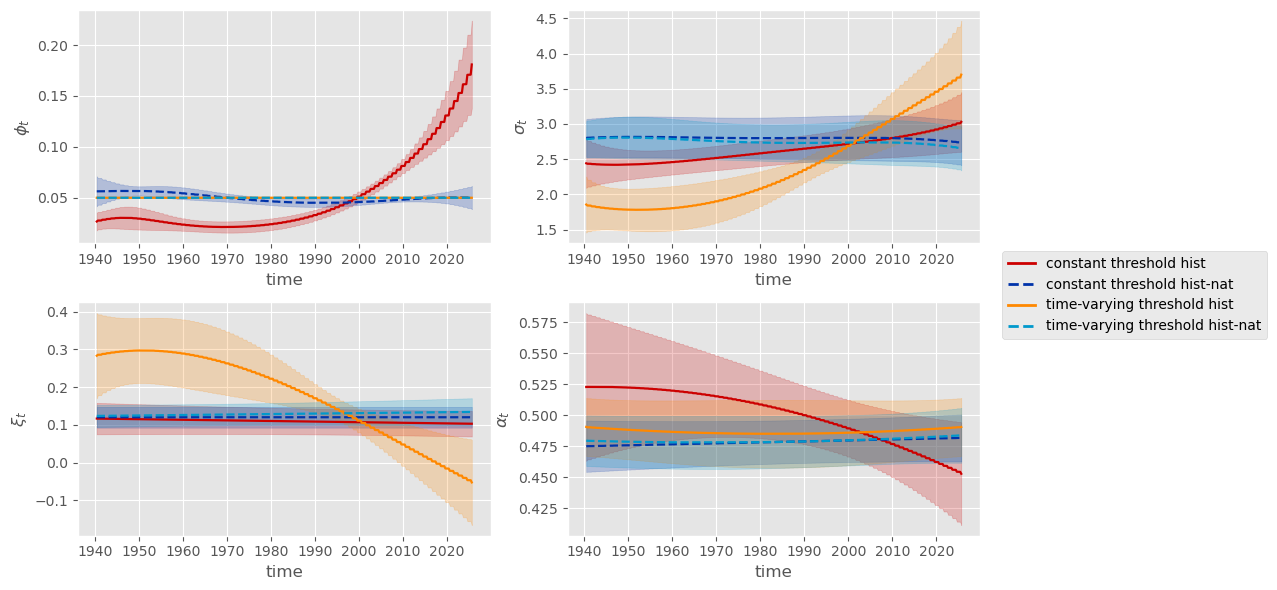

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

PARAM_SPEC = [
    ("phi_hist",   "phi_histnat",   r"$\phi_t$",   0, 0),
    ("scale_hist", "scale_histnat", r"$\sigma_t$", 0, 1),
    ("shape_hist", "shape_histnat", r"$\xi_t$",    1, 0),
    ("alpha_hist", "alpha_histnat", r"$\alpha_t$", 1, 1),
]
C1H, C1N = "#CC0000", "#0033AA"   # Model 1
C2H, C2N = "#FF8800", "#0099CC"   # Model 2
FILL_ALPHA = 0.22

for hist, nat, ylabel, r, c in PARAM_SPEC:
    ax = axs[r, c]
    for ds, ch, cn in [(all_models1, C1H, C1N), (all_models2, C2H, C2N)]:
        t   = ds.time
        m   = getattr(ds, hist).mean("models");  s  = getattr(ds, hist).std("models")
        m2  = getattr(ds, nat).mean("models");   s2 = getattr(ds, nat).std("models")
        ax.plot(t, m,  color=ch, linewidth=1.6)
        ax.fill_between(t, m+s, m-s, color=ch, alpha=FILL_ALPHA)
        ax.plot(t, m2, color=cn, linewidth=1.6, linestyle="--")
        ax.fill_between(t, m2+s2, m2-s2, color=cn, alpha=FILL_ALPHA)
    ax.set_ylabel(ylabel);  ax.set_xlabel("time")

handles = [
    plt.Line2D([0],[0], color=C1H, lw=2,               label="constant threshold hist"),
    plt.Line2D([0],[0], color=C1N, lw=2, linestyle="--",label="constant threshold hist-nat"),
    plt.Line2D([0],[0], color=C2H, lw=2,               label="time-varying threshold hist"),
    plt.Line2D([0],[0], color=C2N, lw=2, linestyle="--",label="time-varying threshold hist-nat"),
]
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig("all_parameters_reg_19_tasmax.png", dpi=300, bbox_inches="tight")

### fig11.png

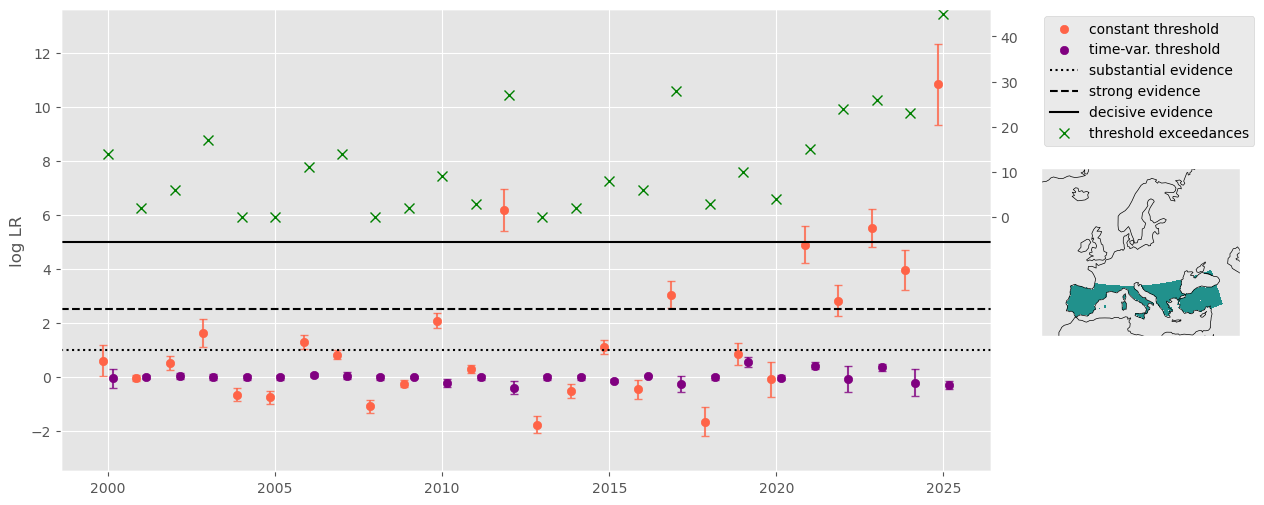

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
yrs = np.arange(2000, 2026)

ax.scatter(yrs - 0.15, list(mu_all_years.values())[-26:],   color="tomato",  label="constant threshold")
ax.errorbar(yrs - 0.15, list(mu_all_years.values())[-26:],
            yerr=list(sigma_all_years.values())[-26:],
            fmt="none", ecolor="tomato", capsize=3, alpha=0.8, zorder=1)

ax.scatter(yrs + 0.15, list(mu_all_years2.values())[-26:],  color="purple",  label="time-var. threshold")
ax.errorbar(yrs + 0.15, list(mu_all_years2.values())[-26:],
            yerr=list(sigma_all_years2.values())[-26:],
            fmt="none", ecolor="purple", capsize=3, alpha=0.8, zorder=1)

ax.set_ylabel("log LR");  ax.set_ylim(-3.5, 13.6)
ax.axhline(1,   linestyle="dotted", color="black", label="substantial evidence")
ax.axhline(2.5, linestyle="--",     color="black", label="strong evidence")
ax.axhline(5,                       color="black", label="decisive evidence")

ax2 = ax.twinx()
ax2.plot(yrs, exceedances_per_year.loc[yrs].values,
         linestyle="None", marker="x", markersize=7,
         color="green", label="threshold exceedances")
ax2.set_ylabel("");  ax2.grid(False)

y1_min, y1_max = ax.get_ylim()
y2_max = exceedances_per_year.loc[yrs].max()
rel6   = (6 - y1_min) / (y1_max - y1_min)
ax2.set_ylim(-rel6 / (1 - rel6) * y2_max, y2_max + 1)
ax2.set_yticks(np.arange(0, y2_max + 2, 10))

lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, loc="upper left", bbox_to_anchor=(1.05, 1))

inset_ax = fig.add_axes([0.915, 0.335, 0.22, 0.28],
                         projection=ccrs.Orthographic(10.49, 47.19))
(era5_ds.isel(time=0) / era5_ds.isel(time=0)).vec.sel(mode=1).plot(
    ax=inset_ax, transform=ccrs.PlateCarree(), add_colorbar=False)
inset_ax.coastlines("110m")
inset_ax.set_extent((-15.31, 44.19, 31.19, 72.20), crs=ccrs.PlateCarree())
inset_ax.set_title("")

plt.savefig("fig11.png", dpi=400, bbox_inches="tight")

### summer_compare.png

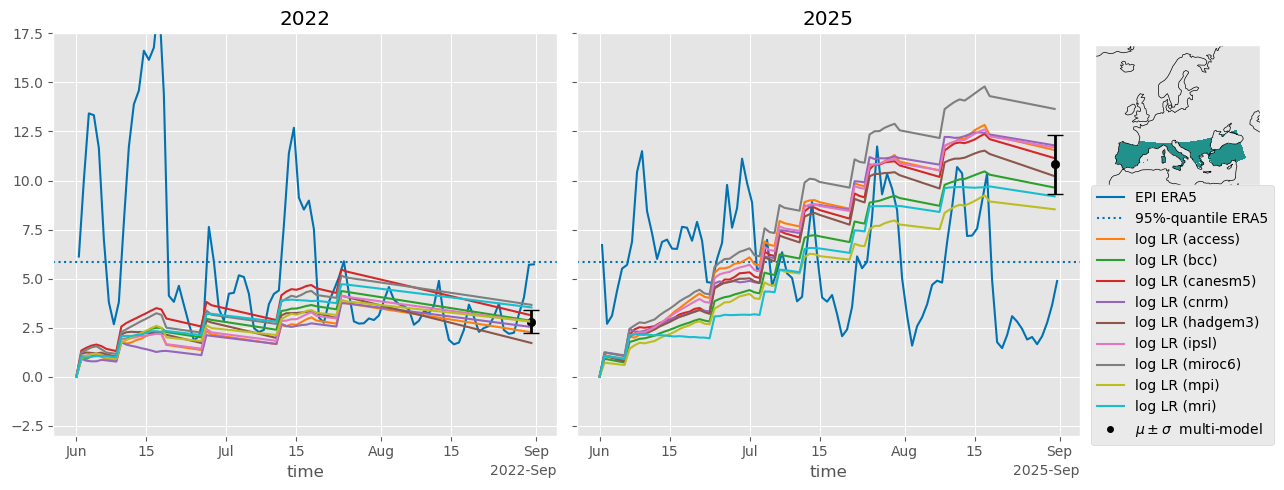

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

ll_2022 = {m: pr1[m][1][-4] - pr1[m][2][-4] for m in list(MODELS)}
ll_2025 = {m: pr1[m][1][-1] - pr1[m][2][-1] for m in list(MODELS)}

plot_epi_panel(ax[0], 2022, ll_2022, era5_ds)
plot_epi_panel(ax[1], 2025, ll_2025, era5_ds)

ax[0].scatter(pd.date_range("2022-08-31", periods=1),
              mu_all_years[2022], color="black")
ax[0].errorbar(pd.date_range("2022-08-31", periods=1),
               np.array(list(mu_all_years.values()))[-4],
               np.array(list(sigma_all_years.values()))[-4],
               color="black", linewidth=2, capsize=6)

ax[1].scatter(pd.date_range("2025-08-31", periods=1),
              np.array(list(mu_all_years.values()))[-1], color="black")
ax[1].errorbar(pd.date_range("2025-08-31", periods=1),
               np.array(list(mu_all_years.values()))[-1],
               np.array(list(sigma_all_years.values()))[-1],
               color="black", linewidth=2, capsize=6)

inset_ax = fig.add_axes([0.99, 0.62, 0.17, 0.28],
                         projection=ccrs.Orthographic(10.49, 47.19))
(era5_ds.isel(time=0) / era5_ds.isel(time=0)).vec.sel(mode=1).plot(
    ax=inset_ax, transform=ccrs.PlateCarree(), add_colorbar=False)
inset_ax.coastlines("110m")
inset_ax.set_extent((-15.31, 44.19, 31.19, 72.20), crs=ccrs.PlateCarree())
inset_ax.set_title("")

black_pt = Line2D([0],[0], marker="o", color="black", linestyle="none",
                  markersize=4, label=r"$\mu \pm \sigma$  multi-model")
handles, labels = ax[1].get_legend_handles_labels()
handles.append(black_pt);  labels.append(r"$\mu \pm \sigma$  multi-model")
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.99, 0.36))
plt.tight_layout()
plt.savefig("summer_compare.png", dpi=300, bbox_inches="tight")